In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/oulad/"

studentInfo = pd.read_csv(path + "studentInfo.csv")
studentVle = pd.read_csv(path + "studentVle.csv")
studentAssessment = pd.read_csv(path + "studentAssessment.csv")
assessments = pd.read_csv(path + "assessments.csv")
courses = pd.read_csv(path + "courses.csv")
vle = pd.read_csv(path + "vle.csv")
studentRegistration = pd.read_csv(path + "studentRegistration.csv")

In [ ]:
studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

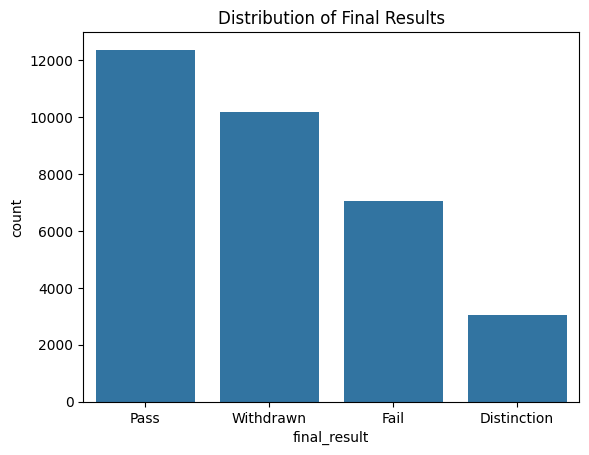

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='final_result', data=studentInfo)

plt.title("Distribution of Final Results")
plt.show()

Distribution of Final Results

In this step, a visualization of the distribution of students’ final academic outcomes was generated using the Seaborn and Matplotlib libraries in Python. The libraries were first imported using the commands import seaborn as sns and import matplotlib.pyplot as plt. Seaborn is a statistical visualization library built on top of Matplotlib, which allows for easier and more visually appealing data exploration.

The function sns.countplot() was used to create a count-based bar chart showing the number of occurrences of each category within the variable final_result from the studentInfo dataset. This variable represents the final academic outcome of each student in the course and includes four possible categories: Pass, Withdrawn, Fail, and Distinction. The argument x='final_result' specifies that the categories of this variable should be displayed on the horizontal axis, while the parameter data=studentInfo tells the function to use the studentInfo dataframe as the data source.

After generating the plot, the title of the visualization was set using the command plt.title("Distribution of Final Results") in order to clearly describe what the chart represents. Finally, plt.show() was used to display the visualization output.

The resulting figure provides an overview of the class distribution within the dataset. From the visualization, it can be observed that the majority of students fall into the Pass category, followed by Withdrawn, Fail, and Distinction. This observation is important because it reveals a class imbalance in the dataset, where the number of students who successfully pass the course is significantly larger than those who fail or withdraw. In machine learning classification tasks, such imbalances can negatively affect model performance, as models may become biased toward the majority class.

Identifying this imbalance at an early stage of the analysis is essential because it justifies the need for data balancing techniques, such as the Synthetic Minority Oversampling Technique (SMOTE), which is later applied in the modeling pipeline to improve the model’s ability to correctly detect at-risk students.

Overall, this visualization serves as an exploratory data analysis step, helping to understand the structure of the dataset and the distribution of student outcomes before proceeding to feature engineering and predictive modeling.

| Outcome     | Meaning             |
| ----------- | ------------------- |
| Pass        | student passed      |
| Distinction | high grade          |
| Fail        | student failed      |
| Withdrawn   | student dropped out |


In [ ]:
studentInfo['at_risk'] = studentInfo['final_result'].apply(
    lambda x: 1 if x in ['Fail','Withdrawn'] else 0
)

studentInfo[['final_result','at_risk']].head()

,final_result,at_risk
0,Pass,0
1,Pass,0
2,Withdrawn,1
3,Pass,0
4,Pass,0


Creation of the At-Risk Student Variable

In this step, a new variable named at_risk was created in the studentInfo dataset in order to transform the original categorical student outcomes into a binary classification target variable suitable for machine learning models. The original dataset includes a column called final_result, which represents the final academic outcome of each student in the course. This variable contains four possible categories: Pass, Distinction, Fail, and Withdrawn.

For the purpose of predicting students who may require academic intervention, these categories were converted into a binary variable representing whether a student is considered at risk of unsuccessful course completion. Students whose final result was Fail or Withdrawn were classified as at-risk students, since these outcomes indicate either unsuccessful completion of the course or dropping out before completion. In contrast, students with outcomes Pass or Distinction were classified as not at risk, as they successfully completed the course.

To perform this transformation, the apply() function was used on the final_result column. The apply() method allows a custom function to be executed on each row of the column. Inside this function, a lambda expression was used to implement the conditional logic. The lambda function checks whether the value of final_result belongs to the list ['Fail', 'Withdrawn']. If this condition is true, the function returns the value 1, indicating that the student is considered at risk. Otherwise, it returns 0, indicating that the student is not at risk.

As a result, the new column at_risk becomes a binary indicator variable where:

1 represents students who failed or withdrew from the course

0 represents students who passed or obtained distinction

This transformation is an important preprocessing step because most classification algorithms require a numerical target variable rather than categorical labels. Converting the academic outcomes into a binary variable simplifies the prediction task into a binary classification problem, where the objective of the machine learning model is to distinguish between students at risk of failure or withdrawal and those likely to complete the course successfully.

After creating the new variable, the command
studentInfo[['final_result','at_risk']].head() was used to display the first five rows of the dataset. This step serves as a verification process to ensure that the transformation was applied correctly and that the at_risk column accurately reflects the intended classification based on the original final_result values.

This binary variable will serve as the target variable (dependent variable) in the predictive modeling stage, where machine learning algorithms will be trained to identify students who are at risk based on engagement, demographic, and academic performance features extracted from the dataset.


In [ ]:
studentInfo['at_risk'].value_counts()

,count
at_risk,
1,17208
0,15385


In [ ]:
engagement = studentVle.groupby(
    ['id_student','code_module','code_presentation']
)['sum_click'].agg(['sum','mean','count']).reset_index()

engagement.columns = [
    'id_student','code_module','code_presentation',
    'total_clicks','avg_clicks','activity_count'
]

engagement.head()

,id_student,code_module,code_presentation,total_clicks,avg_clicks,activity_count
0,6516,AAA,2014J,2791,4.216012,662
1,8462,DDD,2013J,646,2.153333,300
2,8462,DDD,2014J,10,2.500000,4
3,11391,AAA,2013J,934,4.765306,196
4,23629,BBB,2013B,161,2.728814,59


Extraction of Student Engagement Features from the Virtual Learning Environment

In this stage of the analysis, engagement-related features were extracted from the Virtual Learning Environment (VLE) interaction dataset (studentVle). The purpose of this step is to quantify the level of student activity within the online learning platform, as student engagement has been widely recognized in learning analytics research as a strong indicator of academic success or potential risk of failure.

The studentVle dataset records every interaction between a student and the online learning platform. Each row in this dataset represents a recorded activity performed by a student, such as accessing course materials, viewing learning resources, or interacting with course content. One of the key variables in this dataset is sum_click, which represents the number of clicks or interactions a student made with a particular learning resource.

Since the raw dataset contains multiple rows for each student—one for every interaction—it is necessary to aggregate these records into a single set of engagement metrics for each student. To achieve this, the groupby() function from the Pandas library was used. The dataset was grouped according to three identifiers: id_student, code_module, and code_presentation. These variables uniquely identify each student within a specific course module and course presentation (i.e., the semester or academic session).

After grouping the dataset by these identifiers, the sum_click variable was aggregated using three statistical measures: sum, mean, and count. These metrics provide different perspectives on student engagement:

Sum (sum) calculates the total number of clicks performed by a student throughout the course. This value represents the overall amount of interaction the student had with the learning platform and serves as an indicator of total engagement.

Mean (mean) calculates the average number of clicks per recorded interaction, providing an estimate of the typical interaction intensity of the student.

Count (count) calculates the number of interaction records associated with the student, effectively measuring how frequently the student accessed course materials.

After performing the aggregation, the resulting dataset was reset using the reset_index() function. This operation converts the grouped indices back into standard columns, ensuring that the dataset retains a tabular structure suitable for further analysis and merging with other datasets.

To improve the readability and interpretability of the resulting dataset, the column names were then manually renamed using the engagement.columns assignment. The new column names were defined as:

total_clicks – representing the total number of interactions performed by the student

avg_clicks – representing the average number of clicks per interaction

activity_count – representing the total number of recorded interaction events

These newly created features serve as quantitative indicators of student engagement with the learning platform. In learning analytics and early warning systems, such engagement metrics are frequently used as predictive variables because students who interact more frequently with course materials tend to have a higher probability of successfully completing the course, whereas students with low interaction levels are more likely to withdraw or fail.

Finally, the command engagement.head() was used to display the first five rows of the newly generated engagement dataset. This step serves as a verification process to ensure that the aggregation and feature creation were performed correctly before proceeding to the next stage of the data integration and modeling pipeline.

In [ ]:
data = pd.merge(
    studentInfo,
    engagement,
    on=['id_student','code_module','code_presentation'],
    how='left'
)

data['total_clicks'] = data['total_clicks'].fillna(0)

print("Merged dataset shape:", data.shape)

Merged dataset shape: (32593, 16)


Merging Student Performance Data with Engagement Features

After extracting the engagement features from the Virtual Learning Environment dataset, the next step was to combine these features with the main student dataset. This integration step is necessary because the engagement metrics and the student outcome information exist in separate datasets. In order to build a predictive model for identifying at-risk students, all relevant information must be consolidated into a single analytical dataset.

To accomplish this, the pd.merge() function from the Pandas library was used. The merge operation combines the studentInfo dataset, which contains student demographic information and final academic results, with the engagement dataset that was previously created from the VLE interaction logs.

The merging process was performed using three key identifiers: id_student, code_module, and code_presentation. These attributes uniquely identify each student within a particular course module and academic session. By using these fields as the merging keys, the engagement statistics for each student can be accurately aligned with their academic performance data.

A left join (how='left') was used in this merge operation. This means that all records from the studentInfo dataset are preserved in the resulting dataset, even if some students do not have corresponding engagement records in the engagement dataset. This decision is important because the objective of the analysis is to evaluate every student in the dataset, including those who may have had little or no recorded activity in the learning platform.

After performing the merge, some students may have missing values in the total_clicks variable. These missing values occur when a student has no recorded interaction with the Virtual Learning Environment. Instead of leaving these values as missing, the fillna(0) function was applied to replace them with zero. This transformation ensures that students with no engagement are explicitly represented as having zero interactions, rather than being treated as missing data. From a modeling perspective, this distinction is critical because the absence of activity can be an important signal when predicting students who are at risk of failing or withdrawing from the course.

Finally, the shape of the merged dataset was printed using the data.shape command. The output (32593, 16) indicates that the dataset contains 32,593 observations (students) and 16 variables (features) after merging the two datasets. This confirms that the integration process was successful and that the dataset now contains both student performance information and engagement-related features, which can be used in the subsequent machine learning modeling stage.

The resulting merged dataset forms the final analytical dataset that will be used to train and evaluate predictive models for identifying students who may be academically at risk.

In [ ]:
studentAssessment = pd.merge(
    studentAssessment,
    assessments[['id_assessment','assessment_type']],
    on='id_assessment'
)

assessment_features = studentAssessment.groupby('id_student')['score'].agg(
    ['mean','max','min','count']
).reset_index()

assessment_features.columns = [
    'id_student',
    'avg_score',
    'max_score',
    'min_score',
    'num_assessments'
]

assessment_features.head()

,id_student,avg_score,max_score,min_score,num_assessments
0,6516,61.800000,77.0,48.0,5
1,8462,87.000000,93.0,83.0,7
2,11391,82.000000,85.0,78.0,5
3,23629,82.500000,100.0,63.0,4
4,23698,74.444444,94.0,56.0,9


Extraction of Student Assessment Performance Features

In addition to engagement metrics derived from the Virtual Learning Environment interactions, assessment performance indicators were also extracted to capture the academic performance of each student. Assessment data provides important insights into a student’s learning progress, as scores obtained from quizzes, assignments, and exams reflect their understanding of course material. These features are therefore valuable predictors when building models to identify students who may be at risk of failing or withdrawing from a course.

The first step involved merging two datasets: studentAssessment and assessments. The studentAssessment dataset contains the scores obtained by students for each assessment activity, while the assessments dataset provides metadata about these assessments, including the assessment type (for example, exam or assignment). To integrate these two sources of information, the pd.merge() function was used with id_assessment as the merging key. This operation ensures that each student’s score is associated with the correct type of assessment.

Once the datasets were combined, the next step was to generate summary performance features for each student. Since students may complete multiple assessments throughout a course, it is necessary to aggregate their scores into meaningful statistical indicators. To accomplish this, the groupby() function was applied using id_student as the grouping variable. This operation groups all assessment records belonging to the same student.

After grouping the data, several statistical measures were computed using the agg() function on the score variable. Four key metrics were generated:

Mean (mean) – represents the average score achieved by the student across all assessments. This value provides a general measure of the student’s overall academic performance.

Maximum (max) – indicates the highest score obtained by the student in any assessment. This feature may reflect the student’s peak performance level.

Minimum (min) – represents the lowest score obtained by the student. This metric can highlight periods of difficulty or poor performance.

Count (count) – represents the number of assessment activities completed by the student. This variable indicates the student’s participation level in evaluation activities.

After calculating these statistics, the reset_index() function was used to convert the grouped results back into a standard tabular structure. This ensures that id_student remains a regular column that can later be used to merge these features with other datasets.

To improve clarity and interpretability, the columns of the resulting dataset were renamed using the assessment_features.columns assignment. The new column names were defined as:

avg_score – the average assessment score for each student

max_score – the highest score obtained by the student

min_score – the lowest score obtained by the student

num_assessments – the total number of assessments completed by the student

These newly created variables provide a summarized representation of student academic performance across all assessments. In learning analytics research, such statistical summaries are frequently used as predictive features, as students with consistently low scores or limited assessment participation are more likely to experience academic difficulties.

Finally, the assessment_features.head() command was executed to display the first few rows of the resulting dataset. This step serves as a verification process to confirm that the aggregation and feature generation were performed correctly before integrating these features into the main analytical dataset used for machine learning modeling.

In [ ]:
data = pd.merge(
    data,
    assessment_features,
    on='id_student',
    how='left'
)

data.fillna(0, inplace=True)

data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,at_risk,total_clicks,avg_clicks,activity_count,avg_score,max_score,min_score,num_assessments
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,934.0,4.765306,196.0,82.0,85.0,78.0,5.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,1435.0,3.337209,430.0,66.4,70.0,60.0,5.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,281.0,3.697368,76.0,0.0,0.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,2158.0,3.254902,663.0,76.0,88.0,71.0,5.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,1034.0,2.937500,352.0,54.4,75.0,30.0,5.0


Integrating Assessment Features into the Main Analytical Dataset

After generating the assessment performance indicators, the next step involved integrating these newly created features into the main analytical dataset. At this stage, the dataset data already contained student demographic information and engagement features derived from the Virtual Learning Environment interactions. To create a comprehensive dataset suitable for predictive modeling, the assessment-based features needed to be merged with this existing dataset.

This integration was performed using the pd.merge() function from the Pandas library. The merge operation combined the existing dataset data with the assessment_features dataset that was created in the previous step. The merging key used for this operation was id_student, which uniquely identifies each student across the datasets. By using this identifier, the assessment performance indicators could be accurately aligned with the corresponding student records.

A left join (how='left') strategy was used during the merge process. This ensures that all student records present in the main dataset are retained, even if some students do not have corresponding assessment records in the assessment_features dataset. This is an important design choice because some students may have incomplete assessment data or may not have participated in certain assessments. Preserving all records allows the model to evaluate every student while still incorporating assessment-related information when available.

Following the merge operation, the dataset may contain missing values in some of the newly added assessment feature columns. These missing values occur when a student does not have recorded scores or assessment activity in the dataset. To address this issue, the fillna(0) function was applied to the entire dataset using the parameter inplace=True, which directly updates the existing dataset without creating a new copy.

Replacing missing values with zero ensures that students without recorded assessments are represented with neutral values rather than leaving missing entries that could interfere with machine learning algorithms. In the context of predictive modeling, this approach treats the absence of assessment activity as an informative signal that may contribute to identifying students who are academically at risk.

In [ ]:
features = [
    'num_of_prev_attempts',
    'studied_credits',
    'total_clicks',
    'avg_clicks',
    'activity_count',
    'avg_score',
    'max_score',
    'min_score',
    'num_assessments'
]

X = data[features]
y = data['at_risk']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (32593, 9)


Feature Selection and Construction of the Prediction Dataset

After integrating the engagement and assessment features into the main dataset, the next step involved selecting the most relevant variables to be used as input features for the predictive model. Feature selection is a crucial step in machine learning workflows because it determines which attributes will be used by the algorithm to learn patterns that distinguish between students who are at risk and those who successfully complete the course.

In this implementation, a list named features was created to store the selected predictor variables. These variables represent a combination of academic history, engagement behavior, and assessment performance, which are considered important indicators of student success in learning analytics studies.

The selected features include:

num_of_prev_attempts – the number of previous attempts a student has made to complete the module. A higher number of attempts may indicate prior academic difficulties.

studied_credits – the number of credits the student is currently studying, which reflects the student’s academic workload.

total_clicks – the total number of interactions a student has had with the learning platform, representing overall engagement.

avg_clicks – the average number of clicks per interaction, indicating the intensity of student activity.

activity_count – the total number of learning platform interaction events recorded for the student.

avg_score – the average score achieved across all assessments completed by the student.

max_score – the highest score obtained by the student in any assessment.

min_score – the lowest score obtained by the student in an assessment.

num_assessments – the number of assessments completed by the student.

These features collectively capture multiple aspects of student behavior and performance, including prior academic experience, level of participation in the online learning environment, and assessment outcomes.

Once the relevant features were defined, the feature matrix X was created by selecting these columns from the dataset using the command:

X = data[features]

The feature matrix represents the input variables that will be used by the machine learning algorithm to learn predictive patterns.

Next, the target variable y was defined as:

y = data['at_risk']

The at_risk variable was created earlier in the analysis and represents the classification target. Students labeled with 1 are considered at risk (those who failed or withdrew from the course), while students labeled with 0 represent those who successfully completed the course.

Finally, the shape of the feature matrix was printed using the command:

print("Feature matrix shape:", X.shape)

The output (32593, 9) indicates that the dataset contains 32,593 student records and 9 predictive features. This confirms that the feature selection process successfully created the input dataset required for training and evaluating the machine learning models in the next stage of the analysis.

In [ ]:
transformer = PowerTransformer(method='yeo-johnson')

X_transformed = transformer.fit_transform(X)

print("Normalization complete")

Normalization complete


Feature Normalization Using the Yeo–Johnson Transformation

Before training the machine learning models, it is important to ensure that the numerical features are properly scaled and normalized. In many real-world datasets, variables may have different ranges and may also exhibit skewed distributions. Such variations can negatively affect the performance of machine learning algorithms, particularly those that rely on distance calculations or statistical assumptions about feature distributions.

To address this issue, a power transformation technique was applied to the feature matrix using the PowerTransformer class from the Scikit-learn library. Specifically, the Yeo–Johnson transformation method was selected by setting the parameter:

method = 'yeo-johnson'

The Yeo–Johnson transformation is a statistical normalization technique that aims to make data distributions more Gaussian-like (normally distributed). Unlike other transformations such as the Box–Cox transformation, the Yeo–Johnson method has the advantage of handling both positive and negative values, making it more flexible for datasets that may contain different ranges of numeric values.

The transformation process was implemented in two steps. First, the PowerTransformer object was created and stored in the variable transformer:

transformer = PowerTransformer(method='yeo-johnson')

This object defines the transformation method that will later be applied to the dataset.

Next, the transformation was applied to the feature matrix using the fit_transform() function:

X_transformed = transformer.fit_transform(X)

This function performs two operations simultaneously. The fit() component analyzes the distribution of each feature in the dataset and calculates the optimal transformation parameters. The transform() component then applies the calculated transformation to the data, producing a normalized feature matrix.

The resulting dataset, stored in X_transformed, represents the normalized version of the original feature matrix. This transformed dataset maintains the same structure as the original features but ensures that the values are distributed in a way that improves model stability and performance.

In [ ]:
smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X_transformed, y)

print("Balanced dataset shape:", X_balanced.shape)

Balanced dataset shape: (34416, 9)


Handling Class Imbalance Using SMOTE

In many educational datasets, the number of students who successfully complete a course is typically much larger than the number of students who fail or withdraw. This creates a class imbalance problem, where one class (successful students) significantly outnumbers the other class (at-risk students). If this imbalance is not addressed, machine learning models may become biased toward predicting the majority class, resulting in poor detection of students who are actually at risk.

To mitigate this issue, the Synthetic Minority Over-sampling Technique (SMOTE) was applied to the dataset. SMOTE is a widely used data resampling method that generates synthetic samples for the minority class rather than simply duplicating existing observations. This approach helps balance the dataset while preserving the underlying structure of the data.

The SMOTE algorithm was implemented using the SMOTE class from the imbalanced-learn (imblearn) library. The following command was used to initialize the SMOTE object:

smote = SMOTE(random_state=42)

The parameter random_state=42 ensures that the resampling process is reproducible. This means that the same synthetic samples will be generated each time the code is executed, which is important for maintaining consistency in experimental results.

Once the SMOTE object was created, the fit_resample() method was applied to the normalized feature matrix (X_transformed) and the target variable (y). This method performs two operations simultaneously. First, it analyzes the distribution of the minority class (students labeled as at risk). Then, it generates synthetic samples by interpolating between existing minority class observations.

The resampled feature matrix and target variable were stored in the variables X_balanced and y_balanced, respectively:

X_balanced, y_balanced = smote.fit_resample(X_transformed, y)

After applying SMOTE, the dataset becomes balanced, meaning that the number of at-risk students and non-at-risk students is approximately equal. This balanced dataset allows machine learning models to learn patterns associated with both classes more effectively, improving the model’s ability to detect students who may be at risk of failing or withdrawing.

Finally, the shape of the balanced dataset was printed using the command:

print("Balanced dataset shape:", X_balanced.shape)

The output (34416, 9) indicates that the dataset now contains 34,416 observations and 9 predictive features. The increase in the number of observations compared to the original dataset confirms that additional synthetic samples were generated for the minority class during the SMOTE resampling process.

The balanced dataset will be used in the next stage of the workflow to train and evaluate machine learning models designed to predict students who may be academically at risk.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42
)

Splitting the Dataset into Training and Testing Sets

After balancing the dataset using the SMOTE technique, the next step involved dividing the data into separate training and testing subsets. This step is essential in machine learning workflows because it allows the predictive model to be trained on one portion of the data and evaluated on another portion that the model has not previously seen. This separation helps ensure that the model's performance reflects its ability to generalize to new and unseen data rather than simply memorizing patterns from the training dataset.

The dataset splitting was performed using the train_test_split() function from the Scikit-learn library. This function randomly partitions the dataset into two groups: one for training the model and the other for evaluating its predictive performance.

In this implementation, the balanced feature matrix X_balanced and the corresponding target variable y_balanced were provided as inputs to the function. The dataset was divided using the parameter test_size = 0.2, which indicates that 20% of the data is reserved for testing, while the remaining 80% is used for training the model. This ratio is commonly used in machine learning experiments because it provides sufficient data for model training while still maintaining a reliable test set for evaluation.

The command used for this process was:

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42
)

The parameter random_state = 42 was included to ensure reproducibility. By fixing the random seed, the same training and testing partitions will be generated each time the code is executed. This is important for maintaining consistent experimental results and enabling the experiment to be replicated.

After executing this operation, four separate datasets were created:

X_train – the training feature set used to train the machine learning models

X_test – the testing feature set used to evaluate model performance

y_train – the training labels corresponding to the training feature set

y_test – the testing labels corresponding to the testing feature set

The training dataset will be used to train the predictive models, while the testing dataset will later be used to assess the models' ability to correctly identify students who are at risk of failing or withdrawing from the course.

This step prepares the dataset for the model training phase, where machine learning algorithms such as Random Forest or other classification methods can be applied to predict at-risk students based on engagement, assessment, and demographic features.

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test,lr_pred))
print(classification_report(y_test,lr_pred))

Logistic Regression Accuracy: 0.860691458454387
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      3478
           1       0.88      0.83      0.86      3406

    accuracy                           0.86      6884
   macro avg       0.86      0.86      0.86      6884
weighted avg       0.86      0.86      0.86      6884



Machine Learning Model Training and Evaluation
Logistic Regression Model

The first predictive model implemented in this study was Logistic Regression, a widely used statistical classification algorithm that estimates the probability of a binary outcome. In this context, Logistic Regression was used to predict whether a student is at risk (1) or not at risk (0) based on engagement, academic performance, and historical academic behavior features.

The model was initialized using the Scikit-learn LogisticRegression class. The parameter max_iter = 1000 was specified to ensure that the optimization algorithm has enough iterations to converge during model training. Logistic Regression models often require additional iterations when working with larger datasets or normalized feature spaces.

The model was then trained using the training dataset through the fit() method:

lr.fit(X_train, y_train)

This step allows the algorithm to learn the relationship between the input features and the target variable by estimating the model coefficients that best separate the two classes.

After training, predictions were generated for the testing dataset using:

lr_pred = lr.predict(X_test)

The model's performance was evaluated using accuracy and the classification report, which includes precision, recall, and F1-score metrics.

The Logistic Regression model achieved an accuracy of approximately 0.86 (86%), indicating that the model correctly classified about 86% of the students in the testing dataset. The evaluation metrics also show balanced performance across both classes, with precision and recall values ranging between 0.83 and 0.89.

These results indicate that Logistic Regression is capable of identifying patterns associated with at-risk students, although there is still room for improvement when capturing more complex relationships in the data.

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

Random Forest Accuracy: 0.8919233004067403
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      3478
           1       0.92      0.85      0.89      3406

    accuracy                           0.89      6884
   macro avg       0.89      0.89      0.89      6884
weighted avg       0.89      0.89      0.89      6884



Random Forest Model

The second model implemented in this study was the Random Forest Classifier, an ensemble machine learning algorithm that constructs multiple decision trees and combines their predictions to produce a final classification result. Random Forest models are known for their ability to capture non-linear relationships and complex feature interactions, making them particularly effective for structured datasets.

The model was initialized using:

rf = RandomForestClassifier(n_estimators=200)

The parameter n_estimators = 200 specifies that the model will build 200 decision trees. Increasing the number of trees generally improves model stability and predictive performance, as the final prediction is based on the majority vote of multiple trees.

The model was trained using the training dataset:

rf.fit(X_train, y_train)

Once the training process was complete, predictions were generated on the testing dataset:

rf_pred = rf.predict(X_test)

Model performance was evaluated using accuracy and classification metrics.

The Random Forest model achieved an accuracy of approximately 0.89 (89%), which is higher than the Logistic Regression model. The classification report indicates strong predictive performance, with precision values reaching 0.92 for the at-risk class and recall values above 0.85.

These results suggest that Random Forest is better able to capture complex behavioral patterns in the student data, particularly those related to engagement and assessment performance. As a result, it provides a more accurate model for identifying students who may be at risk.

In [ ]:
svm = SVC(probability=True)

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test,svm_pred))
print(classification_report(y_test,svm_pred))

SVM Accuracy: 0.8787042417199302
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      3478
           1       0.93      0.82      0.87      3406

    accuracy                           0.88      6884
   macro avg       0.88      0.88      0.88      6884
weighted avg       0.88      0.88      0.88      6884



Support Vector Machine Model

The third model implemented in the study was the Support Vector Machine (SVM) classifier. SVM is a powerful supervised learning algorithm that attempts to find the optimal decision boundary (hyperplane) that separates data points belonging to different classes.

The SVM model was initialized using:

svm = SVC(probability=True)

The parameter probability=True allows the model to compute probability estimates for predictions, which can be useful in later analysis or for ranking students based on risk levels.

The model was trained using the training dataset:

svm.fit(X_train, y_train)

After training, predictions were generated for the testing dataset:

svm_pred = svm.predict(X_test)

Model performance was again evaluated using accuracy and the classification report.

The SVM model achieved an accuracy of approximately 0.88 (88%). The evaluation results indicate strong predictive capability, with recall values reaching 0.94 for the non-risk class and precision values up to 0.93 for the at-risk class. These metrics demonstrate that the model performs well in identifying both classes, although its overall accuracy is slightly lower than that of the Random Forest model.

In [ ]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","SVM"],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,svm_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.860691
1,Random Forest,0.891923
2,SVM,0.878704


Comparative Evaluation of Machine Learning Models

After training and evaluating the three classification models—Logistic Regression, Random Forest, and Support Vector Machine (SVM)—a comparative analysis was conducted to summarize their predictive performance. This step is important because it allows the researcher to clearly identify which model performs best in predicting students who are at risk of failing or withdrawing from a course.

To perform this comparison, a new Pandas DataFrame named results was created. This table was designed to store the names of the implemented models along with their corresponding accuracy scores. The DataFrame was constructed using two columns: "Model", which lists the machine learning algorithms used in the experiment, and "Accuracy", which stores the calculated accuracy values obtained from the evaluation of each model on the testing dataset.

The accuracy values were calculated using the accuracy_score() function from the Scikit-learn library. This function measures the proportion of correctly classified observations in the testing dataset. For each model, the predicted labels were compared with the actual labels (y_test) to determine the overall classification accuracy.

The accuracy values obtained for each model were as follows:

Logistic Regression: 0.8607 (approximately 86%)

Random Forest: 0.8919 (approximately 89%)

Support Vector Machine (SVM): 0.8787 (approximately 88%)

These results were stored in the results DataFrame and displayed as a summary table. The table provides a clear comparison of model performance and makes it easier to determine which algorithm is most effective for the task of predicting at-risk students.

Based on the results, the Random Forest model achieved the highest accuracy, outperforming both Logistic Regression and SVM. This outcome suggests that ensemble learning methods, which combine multiple decision trees, are particularly effective in capturing the complex relationships between student engagement behavior, academic performance, and risk of course failure or withdrawal.

Logistic Regression, although simpler and more interpretable, achieved slightly lower accuracy, indicating that linear models may not fully capture the nonlinear patterns present in the dataset. The Support Vector Machine model demonstrated strong performance but still performed slightly below Random Forest.

This comparative evaluation provides valuable insight into the suitability of different machine learning algorithms for educational data analysis. It also supports the selection of Random Forest as the most effective predictive model in this implementation, which can be used as the foundation for further improvements or extensions to the predictive system.

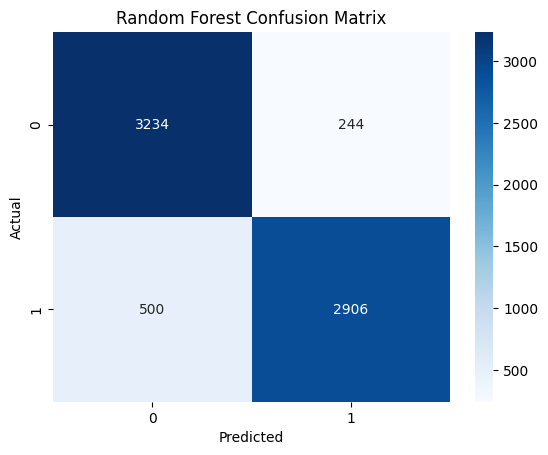

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Confusion Matrix Analysis of the Random Forest Model

To further evaluate the performance of the best-performing model, a confusion matrix was generated for the Random Forest classifier. While accuracy provides a general measure of prediction performance, it does not fully reveal how well the model distinguishes between the two classes. The confusion matrix provides a more detailed breakdown of classification results by showing the number of correct and incorrect predictions for each class.

The confusion matrix was generated using the confusion_matrix() function from the Scikit-learn library. This function compares the actual labels (y_test) with the predicted labels generated by the Random Forest model (rf_pred). The result is a matrix that summarizes how many predictions fall into each classification category.

To visualize the matrix, the Seaborn heatmap function (sns.heatmap) was used. This visualization highlights the number of predictions in each category and makes the interpretation of model performance clearer. The heatmap was configured to display the numerical values within each cell using the parameter annot=True, while the fmt="d" parameter ensures that the values are displayed as integers. Additionally, a blue color palette (cmap="Blues") was used to improve visual clarity.

The confusion matrix produced the following results:

Actual Class	Predicted 0	Predicted 1
0 (Not At Risk)	3234	244
1 (At Risk)	500	2906

These values represent the four key components of classification evaluation:

True Negatives (3234): Students who were correctly predicted as not at risk.

False Positives (244): Students who were incorrectly predicted as at risk even though they were not.

False Negatives (500): Students who were actually at risk but were incorrectly classified as not at risk.

True Positives (2906): Students who were correctly predicted as at risk.

The confusion matrix provides important insights into the model's predictive behavior. The high number of true positives (2906) indicates that the model is effective in identifying students who may be academically at risk. This is particularly important in early warning systems, where correctly identifying struggling students allows institutions to intervene and provide additional support.

At the same time, the number of false negatives (500) indicates that some at-risk students were not detected by the model. While the model performs well overall, reducing these missed cases would further improve the effectiveness of the predictive system.

Overall, the confusion matrix confirms that the Random Forest classifier provides strong predictive performance, with a high number of correct classifications across both classes. This supports the earlier evaluation results, which showed that Random Forest achieved the highest accuracy among the tested models.

The visualization also helps illustrate the model's reliability and provides a clearer understanding of how the predictive system performs when identifying students who may require early academic intervention.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

auc_score = roc_auc_score(y_test, rf_probs)

print("AUC Score:", auc_score)

AUC Score: 0.9614650616559014


| AUC       | Meaning         |
| --------- | --------------- |
| 0.50      | random guessing |
| 0.70–0.80 | acceptable      |
| 0.80–0.90 | very good       |
| 0.90+     | excellent       |


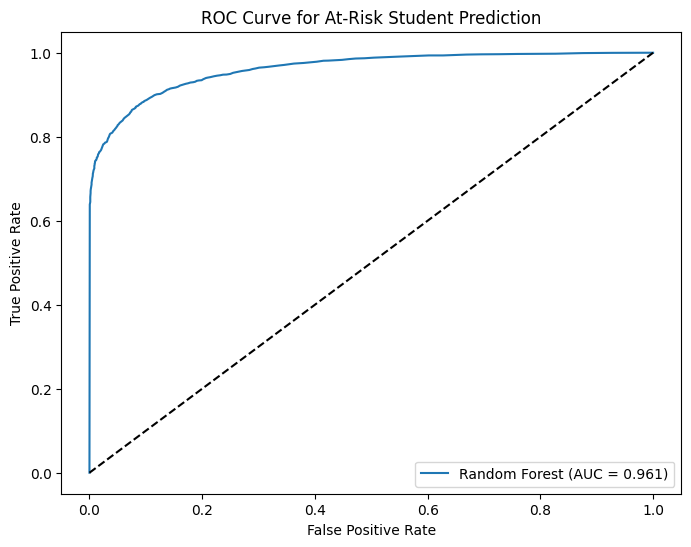

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="Random Forest (AUC = %.3f)" % auc_score)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for At-Risk Student Prediction")

plt.legend()
plt.show()

Receiver Operating Characteristic (ROC) Curve and AUC Evaluation

To further evaluate the predictive performance of the Random Forest model, the Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) metric were calculated. While accuracy and confusion matrices provide useful insights into classification performance, the ROC–AUC analysis offers a more comprehensive evaluation of the model’s ability to distinguish between the two classes across different classification thresholds.

The ROC curve represents the relationship between the True Positive Rate (TPR) and the False Positive Rate (FPR) at various threshold levels. The True Positive Rate, also known as sensitivity or recall, measures the proportion of actual at-risk students that the model correctly identifies. The False Positive Rate measures the proportion of non–at-risk students that are incorrectly classified as at risk.

To compute the ROC curve, the predicted probabilities for the positive class (students classified as at risk) were first obtained using the predict_proba() method of the trained Random Forest model. This method returns probability values instead of binary class predictions. Since the output contains probabilities for both classes, the second column ([:,1]) was selected, which corresponds to the probability that a student belongs to the at-risk class.

The ROC curve values were then calculated using the roc_curve() function from the Scikit-learn library. This function generates three outputs:

False Positive Rate (FPR) values

True Positive Rate (TPR) values

Threshold values used to generate the classification boundaries

In addition to the ROC curve, the Area Under the Curve (AUC) was calculated using the roc_auc_score() function. The AUC score summarizes the ROC curve into a single value that represents the overall discriminative ability of the model. A higher AUC score indicates better model performance in distinguishing between at-risk and non–at-risk students.

The Random Forest model achieved an AUC score of approximately 0.961, which indicates excellent classification performance. In general, AUC values can be interpreted as follows:

AUC Score	Interpretation
0.50	Random guessing
0.70 – 0.80	Acceptable
0.80 – 0.90	Very good
0.90+	Excellent

The obtained AUC score demonstrates that the Random Forest model has a very strong ability to correctly rank students according to their risk level.

To visually represent the model's performance, the ROC curve was plotted using the Matplotlib library. The plot shows the relationship between the true positive rate and false positive rate across all threshold values. A diagonal dashed line was included in the visualization to represent the performance of a random classifier. The Random Forest curve lies significantly above this baseline, confirming the strong predictive capability of the model.

Overall, the ROC curve and AUC evaluation further validate the effectiveness of the Random Forest classifier in predicting at-risk students. The high AUC value indicates that the model is highly reliable in distinguishing between students who are likely to succeed and those who may require early academic intervention.